<a href="https://colab.research.google.com/github/Luckyaman/Home_Work_Assignment_1_CS_5080_Reinforcement-_Learning/blob/main/Home_Work_Assignment_1_CS_5080_Reinforcement__Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import random
import numpy as np
from collections import defaultdict

ACTIONS = ['U', 'D', 'L', 'R']
ACTION_DELTA = {
    'U': (-1, 0),
    'D': (1, 0),
    'L': (0, -1),
    'R': (0, 1)
}


class Maze:
    def __init__(self, size=5, fixed=False, barrier_prob=0.2):
        self.size = size
        self.start = (0, 0)
        self.goal = (size - 1, size - 1)

        if fixed:
            self.barriers = self._fixed_barriers()
        else:
            self.barriers = self._random_barriers(barrier_prob)

    # Fixed 5x5 maze
    def _fixed_barriers(self):
        barriers = set()

        # Third row except first cell
        for j in range(1, 5):
            barriers.add((2, j))

        # Middle of fifth row
        barriers.add((4, 2))

        return barriers

    # Random maze for 8x8 and 12x12
    def _random_barriers(self, p):
        barriers = set()

        for i in range(self.size):
            for j in range(self.size):
                if (i, j) not in [self.start, self.goal]:
                    if random.random() < p:
                        barriers.add((i, j))

        # Ensure start neighbors are free
        barriers.discard((0, 1))
        barriers.discard((1, 0))

        # Ensure goal neighbors are free
        barriers.discard((self.size - 1, self.size - 2))
        barriers.discard((self.size - 2, self.size - 1))

        return barriers

    def valid_actions(self, state):
        actions = []
        for a in ACTIONS:
            di, dj = ACTION_DELTA[a]
            ni, nj = state[0] + di, state[1] + dj

            if 0 <= ni < self.size and 0 <= nj < self.size:
                if (ni, nj) not in self.barriers:
                    actions.append(a)

        return actions

    def step(self, state, action):

        if action not in self.valid_actions(state):
            return state, -1, False

        di, dj = ACTION_DELTA[action]
        next_state = (state[0] + di, state[1] + dj)

        if next_state == self.goal:
            return next_state, 100, True

        return next_state, -1, False


def generate_episode(env, policy):
    episode = []
    state = env.start

    while state != env.goal:

        actions = list(policy[state].keys())
        probs = list(policy[state].values())

        action = random.choices(actions, weights=probs)[0]

        next_state, reward, done = env.step(state, action)
        episode.append((state, action, reward))
        state = next_state

        if done:
            break

    return episode


def monte_carlo_control(env, episodes=8000, gamma=0.9, epsilon=0.1):

    Q = defaultdict(lambda: defaultdict(float))
    returns_count = defaultdict(lambda: defaultdict(int))
    policy = {}

    # Initialize random policy
    for i in range(env.size):
        for j in range(env.size):
            s = (i, j)

            if s not in env.barriers and s != env.goal:
                actions = env.valid_actions(s)
                if actions:
                    prob = 1 / len(actions)
                    policy[s] = {a: prob for a in actions}

    # Monte Carlo Learning
    for ep in range(episodes):

        episode = generate_episode(env, policy)
        G = 0
        visited = set()

        for state, action, reward in reversed(episode):

            G = gamma * G + reward

            if (state, action) not in visited:
                visited.add((state, action))

                returns_count[state][action] += 1
                Q[state][action] += (
                    (G - Q[state][action]) /
                    returns_count[state][action]
                )

                actions = env.valid_actions(state)
                if not actions:
                    continue

                q_values = [Q[state][a] for a in actions]
                best_action = actions[np.argmax(q_values)]

                for a in actions:
                    if a == best_action:
                        policy[state][a] = 1 - epsilon + epsilon / len(actions)
                    else:
                        policy[state][a] = epsilon / len(actions)

    return policy


def print_policy(env, policy):

    arrow = {'U': '↑', 'D': '↓', 'L': '←', 'R': '→'}
    grid = [[' ' for _ in range(env.size)] for _ in range(env.size)]

    for i in range(env.size):
        for j in range(env.size):
            s = (i, j)

            if s in env.barriers:
                grid[i][j] = '█'
            elif s == env.start:
                grid[i][j] = 'S'
            elif s == env.goal:
                grid[i][j] = 'G'
            elif s not in policy:
                grid[i][j] = 'X'   # dead-end state
            else:
                best_action = max(policy[s], key=policy[s].get)
                grid[i][j] = arrow[best_action]

    for row in grid:
        print(' '.join(row))
    print()


if __name__ == "__main__":

    random.seed()
    np.random.seed()

    sizes = [5, 8, 12]

    for size in sizes:

        print(f"\nMaze Size: {size} x {size}\n")

        if size == 5:
            maze = Maze(size=5, fixed=True)
            episodes = 6000
        else:
            maze = Maze(size=size, fixed=False, barrier_prob=0.25)
            episodes = 12000   # larger maze needs more learning

        policy = monte_carlo_control(
            maze,
            episodes=episodes,
            gamma=0.9,
            epsilon=0.1
        )

        print_policy(maze, policy)


Maze Size: 5 x 5

S ← ↓ ↓ ↓
↓ ← ← ↑ ↑
↓ █ █ █ █
→ → → ↓ ↓
→ ↑ █ → G


Maze Size: 8 x 8

S → → ↓ ↓ ↓ █ ↓
→ ↓ ↓ → ↓ → → ↓
↓ → → → → → ↓ ↓
→ ↑ ↑ █ █ █ → ↓
↑ → ↑ ← ← ← █ ↓
█ █ ↑ ↑ ← █ → ↓
→ → ↑ ↑ ← █ ↓ ↓
█ ↑ █ ↑ █ █ → G


Maze Size: 12 x 12

S ↓ █ █ → ← → ↓ ← ← ← ←
→ ↓ ← █ ↑ ↓ █ → ↓ ↓ → ↑
█ ↓ █ ↓ → ↓ ↓ → ↓ ↓ ↑ █
→ → → → → → → → → ↓ █ █
↑ → → ↑ ↑ █ █ ↑ █ ↓ ↓ ↓
█ ↑ ← █ ↑ ← █ ↑ █ ↓ ↓ ↓
→ → ↓ → ↑ █ → ↑ █ ↓ ↓ ↓
█ █ ↓ ↑ → ↓ ↓ █ → ↓ ↓ ↓
█ █ → ↑ █ → ↑ ← █ → ↓ ↓
→ ↓ ← █ → ← → → ↓ → ↓ ↓
↑ ↓ █ █ ↓ → ← ↓ → → → ↓
█ → → → ↑ █ ↑ → ↑ █ → G



In [ ]:
import random
import numpy as np
from collections import defaultdict

ACTIONS = ['U', 'D', 'L', 'R']
ACTION_DELTA = {
    'U': (-1, 0),
    'D': (1, 0),
    'L': (0, -1),
    'R': (0, 1)
}


class Maze:
    def __init__(self, size=5, fixed=False, barrier_prob=0.2):
        self.size = size
        self.start = (0, 0)
        self.goal = (size - 1, size - 1)

        if fixed:
            self.barriers = self._fixed_barriers()
        else:
            self.barriers = self._random_barriers(barrier_prob)

    # Fixed 5x5 maze
    def _fixed_barriers(self):
        barriers = set()

        # Third row except first cell
        for j in range(1, 5):
            barriers.add((2, j))

        # Middle of fifth row
        barriers.add((4, 2))

        return barriers

    # Random maze
    def _random_barriers(self, p):
        barriers = set()

        for i in range(self.size):
            for j in range(self.size):
                if (i, j) not in [self.start, self.goal]:
                    if random.random() < p:
                        barriers.add((i, j))

        # Keep neighbors of start and goal free
        barriers.discard((0, 1))
        barriers.discard((1, 0))
        barriers.discard((self.size - 1, self.size - 2))
        barriers.discard((self.size - 2, self.size - 1))

        return barriers

    def valid_actions(self, state):
        actions = []
        for a in ACTIONS:
            di, dj = ACTION_DELTA[a]
            ni, nj = state[0] + di, state[1] + dj

            if 0 <= ni < self.size and 0 <= nj < self.size:
                if (ni, nj) not in self.barriers:
                    actions.append(a)

        return actions

    def step(self, state, action):

        if action not in self.valid_actions(state):
            return state, -1, False

        di, dj = ACTION_DELTA[action]
        next_state = (state[0] + di, state[1] + dj)

        if next_state == self.goal:
            return next_state, 100, True

        return next_state, -1, False


def generate_episode(env, policy):
    episode = []
    state = env.start

    while state != env.goal:

        actions = list(policy[state].keys())
        probs = list(policy[state].values())

        action = random.choices(actions, weights=probs)[0]

        next_state, reward, done = env.step(state, action)
        episode.append((state, action, reward))
        state = next_state

        if done:
            break

    return episode


def monte_carlo_control(env, episodes=8000, gamma=0.9, epsilon=0.1):

    Q = defaultdict(lambda: defaultdict(float))
    returns_count = defaultdict(lambda: defaultdict(int))
    policy = {}

    episode_lengths = []
    episode_returns = []

    # Initialize equiprobable random policy
    for i in range(env.size):
        for j in range(env.size):
            s = (i, j)

            if s not in env.barriers and s != env.goal:
                actions = env.valid_actions(s)
                if actions:
                    prob = 1 / len(actions)
                    policy[s] = {a: prob for a in actions}

    # Monte Carlo learning
    for ep in range(episodes):

        episode = generate_episode(env, policy)

        # Track learning curve metrics
        total_reward = sum([step[2] for step in episode])
        episode_returns.append(total_reward)
        episode_lengths.append(len(episode))

        G = 0
        visited = set()

        # First-visit MC update
        for state, action, reward in reversed(episode):

            G = gamma * G + reward

            if (state, action) not in visited:
                visited.add((state, action))

                returns_count[state][action] += 1
                Q[state][action] += (
                    (G - Q[state][action]) /
                    returns_count[state][action]
                )

                actions = env.valid_actions(state)
                if not actions:
                    continue

                q_values = [Q[state][a] for a in actions]
                best_action = actions[np.argmax(q_values)]

                for a in actions:
                    if a == best_action:
                        policy[state][a] = 1 - epsilon + epsilon / len(actions)
                    else:
                        policy[state][a] = epsilon / len(actions)

    return policy, episode_lengths, episode_returns


# ===============================
# RUN FOR THREE MAZES
# ===============================

sizes = [5, 8, 12]

results = {}

for size in sizes:

    if size == 5:
        maze = Maze(size=5, fixed=True)
        episodes = 6000
    else:
        maze = Maze(size=size, fixed=False, barrier_prob=0.25)
        episodes = 12000

    policy, lengths, rewards = monte_carlo_control(
        maze,
        episodes=episodes,
        gamma=0.9,
        epsilon=0.1
    )

    results[size] = {
        "episode_lengths": lengths,
        "episode_returns": rewards
    }

# Now results dictionary contains learning curves for:
# 5x5, 8x8, and 12x12


Running experiments for 5 x 5 maze ...
Running experiments for 8 x 8 maze ...
Running experiments for 12 x 12 maze ...


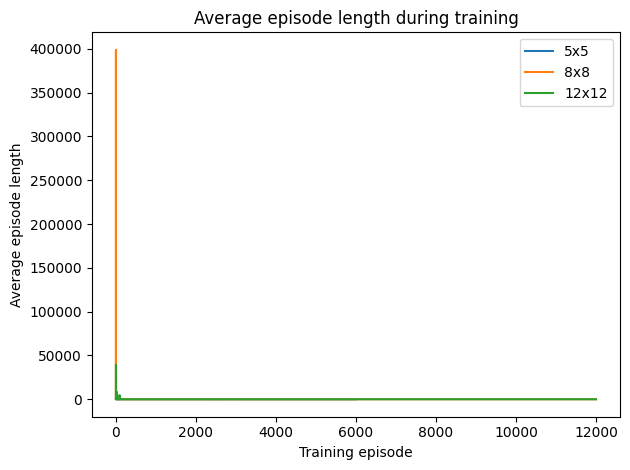

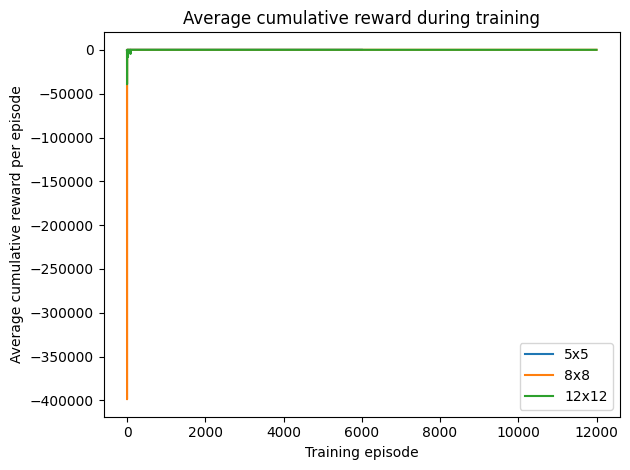


Example learned policies:

Policy for 5 x 5 maze:
S ↓ ↓ → ↓
↓ ← ← ← ←
↓ █ █ █ █
→ → → → ↓
↑ ↑ █ → G



In [ ]:
# ============================================================
# Monte-Carlo control + learning performance metrics
# (average episode length and cumulative reward)
# ============================================================

import random
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

# ---------------------------
# Environment
# ---------------------------

ACTIONS = ['U', 'D', 'L', 'R']

ACTION_DELTA = {
    'U': (-1, 0),
    'D': (1, 0),
    'L': (0, -1),
    'R': (0, 1)
}


class Maze:
    def __init__(self, size=5, fixed=False, barrier_prob=0.2):
        self.size = size
        self.start = (0, 0)
        self.goal = (size - 1, size - 1)

        if fixed:
            self.barriers = self._fixed_barriers()
        else:
            self.barriers = self._random_barriers(barrier_prob)

    # Fixed 5x5 maze
    def _fixed_barriers(self):
        barriers = set()

        # Third row except first cell
        for j in range(1, 5):
            barriers.add((2, j))

        # Middle of fifth row
        barriers.add((4, 2))

        return barriers

    # Random maze
    def _random_barriers(self, p):
        barriers = set()

        for i in range(self.size):
            for j in range(self.size):
                if (i, j) not in [self.start, self.goal]:
                    if random.random() < p:
                        barriers.add((i, j))

        # ensure neighbors of start and goal are free
        barriers.discard((0, 1))
        barriers.discard((1, 0))
        barriers.discard((self.size - 1, self.size - 2))
        barriers.discard((self.size - 2, self.size - 1))

        return barriers

    def valid_actions(self, state):

        actions = []
        for a in ACTIONS:
            di, dj = ACTION_DELTA[a]
            ni, nj = state[0] + di, state[1] + dj

            if 0 <= ni < self.size and 0 <= nj < self.size:
                if (ni, nj) not in self.barriers:
                    actions.append(a)

        return actions

    def step(self, state, action):

        if action not in self.valid_actions(state):
            return state, -1, False

        di, dj = ACTION_DELTA[action]
        next_state = (state[0] + di, state[1] + dj)

        if next_state == self.goal:
            return next_state, 100, True

        return next_state, -1, False


# ---------------------------
# Episode generation
# ---------------------------

def generate_episode(env, policy):

    episode = []
    state = env.start

    while state != env.goal:

        actions = list(policy[state].keys())
        probs = list(policy[state].values())

        action = random.choices(actions, weights=probs)[0]

        next_state, reward, done = env.step(state, action)

        episode.append((state, action, reward))
        state = next_state

        if done:
            break

    return episode


# ---------------------------
# Monte-Carlo control WITH metrics
# ---------------------------

def monte_carlo_control_with_metrics(env,
                                     episodes=8000,
                                     gamma=0.9,
                                     epsilon=0.1):

    Q = defaultdict(lambda: defaultdict(float))
    returns_count = defaultdict(lambda: defaultdict(int))
    policy = {}

    episode_lengths = []
    episode_rewards = []

    # initialize equiprobable policy
    for i in range(env.size):
        for j in range(env.size):
            s = (i, j)

            if s not in env.barriers and s != env.goal:
                actions = env.valid_actions(s)
                if actions:
                    prob = 1 / len(actions)
                    policy[s] = {a: prob for a in actions}

    # training loop
    for ep in range(episodes):

        episode = generate_episode(env, policy)

        # ----- metrics -----
        episode_lengths.append(len(episode))
        episode_rewards.append(sum([r for (_, _, r) in episode]))
        # -------------------

        G = 0
        visited = set()

        for state, action, reward in reversed(episode):

            G = gamma * G + reward

            # First-Visit MC
            if (state, action) not in visited:

                visited.add((state, action))

                returns_count[state][action] += 1

                Q[state][action] += (
                    (G - Q[state][action]) /
                    returns_count[state][action]
                )

                actions = env.valid_actions(state)
                if not actions:
                    continue

                q_values = [Q[state][a] for a in actions]
                best_action = actions[np.argmax(q_values)]

                for a in actions:
                    if a == best_action:
                        policy[state][a] = 1 - epsilon + epsilon / len(actions)
                    else:
                        policy[state][a] = epsilon / len(actions)

    return policy, np.array(episode_lengths), np.array(episode_rewards)


# ---------------------------
# Multiple trials and averaging
# ---------------------------

def run_multiple_trials(size,
                        trials=10,
                        episodes=6000,
                        gamma=0.9,
                        epsilon=0.1):

    all_lengths = []
    all_rewards = []

    for t in range(trials):

        if size == 5:
            env = Maze(size=5, fixed=True)
        else:
            env = Maze(size=size, fixed=False, barrier_prob=0.25)

        _, lengths, rewards = monte_carlo_control_with_metrics(
            env,
            episodes=episodes,
            gamma=gamma,
            epsilon=epsilon
        )

        all_lengths.append(lengths)
        all_rewards.append(rewards)

    all_lengths = np.array(all_lengths)
    all_rewards = np.array(all_rewards)

    return all_lengths.mean(axis=0), all_rewards.mean(axis=0)


# ---------------------------
# Policy visualization
# ---------------------------

def print_policy(env, policy):

    arrow = {'U': '↑', 'D': '↓', 'L': '←', 'R': '→'}
    grid = [[' ' for _ in range(env.size)] for _ in range(env.size)]

    for i in range(env.size):
        for j in range(env.size):
            s = (i, j)

            if s in env.barriers:
                grid[i][j] = '█'
            elif s == env.start:
                grid[i][j] = 'S'
            elif s == env.goal:
                grid[i][j] = 'G'
            elif s not in policy:
                grid[i][j] = 'X'
            else:
                best_action = max(policy[s], key=policy[s].get)
                grid[i][j] = arrow[best_action]

    for row in grid:
        print(' '.join(row))
    print()


# ---------------------------
# Main
# ---------------------------

if __name__ == "__main__":

    random.seed()
    np.random.seed()

    sizes = [5, 8, 12]
    trials = 10

    avg_episode_length = {}
    avg_episode_reward = {}

    for size in sizes:

        if size == 5:
            episodes = 6000
        else:
            episodes = 12000

        print(f"Running experiments for {size} x {size} maze ...")

        avg_len, avg_rew = run_multiple_trials(
            size=size,
            trials=trials,
            episodes=episodes,
            gamma=0.9,
            epsilon=0.1
        )

        avg_episode_length[size] = avg_len
        avg_episode_reward[size] = avg_rew

    # -------------------------------------------------
    # Average episode length
    # -------------------------------------------------

    plt.figure()

    for size in sizes:
        plt.plot(avg_episode_length[size], label=f"{size}x{size}")

    plt.xlabel("Training episode")
    plt.ylabel("Average episode length")
    plt.title("Average episode length during training")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # -------------------------------------------------
    # Average cumulative reward
    # -------------------------------------------------

    plt.figure()

    for size in sizes:
        plt.plot(avg_episode_reward[size], label=f"{size}x{size}")

    plt.xlabel("Training episode")
    plt.ylabel("Average cumulative reward per episode")
    plt.title("Average cumulative reward during training")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # -------------------------------------------------
    # Show one learned policy for each size
    # -------------------------------------------------

    print("\nExample learned policies:\n")

    for size in sizes:

        if size == 5:
            env = Maze(size=5, fixed=True)
            episodes = 6000
        else:
            env = Maze(size=size, fixed=False, barrier_prob=0.25)
            episodes = 12000

        policy, _, _ = monte_carlo_control_with_metrics(
            env,
            episodes=episodes,
            gamma=0.9,
            epsilon=0.1
        )

        print(f"Policy for {size} x {size} maze:")
        print_policy(env, policy)